# Comparaison of samples

Apply to output files from summary_celltypes_IHOPE.py in CSV format.

In [1]:
import sys
from pathlib import Path
#TODO try to remove this somehow
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [9]:
import numpy as np

In [2]:
import importlib
import scripts.comparison as comparison

importlib.reload(comparison)

from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_heatmap,
    plot_celltype_clustermap
)


Define file names and sample names. Use the output from cell 1 to complete cell 2.

In [3]:
# Make a "fill the gap" template
summaries_dir = Path("../results/reports/NEW")
files = sorted(summaries_dir.glob("celltype_summary_*debugged_summary.csv"))

print("name_map = {")
for f in files:
    print(f'    "{f.name}": "",')
print("}")

name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
    "celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "",
 

In [4]:
# Can of course change later to make the plot look prettier
name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14_MedLN_BottomLeft",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14_MedLN_BottomRight",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14_MedLN_TopRight",
    "celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE14_mesLN",
    "celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE20_LN",
    "celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE20_Spleen",
    "celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE26_LN",
    "celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE26_Spleen",
    "celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE27_LN",
    "celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE27_Spleen",
    "celltype_summary_IHOPE39_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE39_LN",
    "celltype_summary_IHOPE39_MesLN_1_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE39_MesLN_1",
    "celltype_summary_IHOPE39_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv": "IHOPE39_Spleen",
}

In [5]:
file_map = {
    sample: summaries_dir / fname
    for fname, sample in name_map.items()
}

In [6]:
# Sanity check
for sample, path in file_map.items():
    print(sample, ": ", path.name)

IHOPE14_MedLN_BottomLeft :  celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE14_MedLN_BottomRight :  celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE14_MedLN_TopRight :  celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE14_mesLN :  celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE20_LN :  celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE20_Spleen :  celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE26_LN :  celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE26_Spleen :  celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE27_LN :  celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_debugged_summary.csv
IHOPE27_Spleen :  celltype_summa

Load data frame

In [7]:
df = load_celltype_summaries(file_map=file_map)

matrix = pivot_for_heatmap(df)

Plot cell type heatmap

In [10]:
# Log scale to improve coloring for low-abundant cell types:
plot_matrix = np.log10(matrix + 0.1)

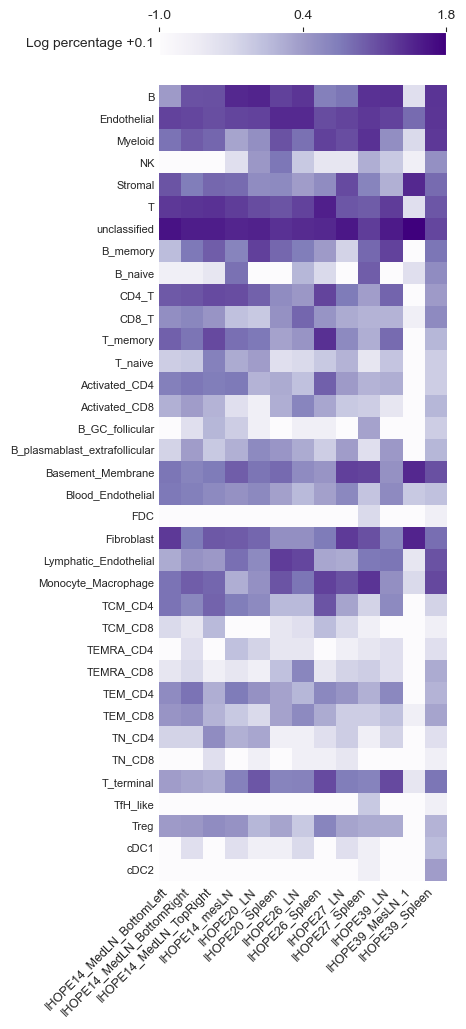

In [11]:
plot_celltype_heatmap(
    plot_matrix,
    scale = "log",
    colorbar_legend="Log percentage +0.1"
)

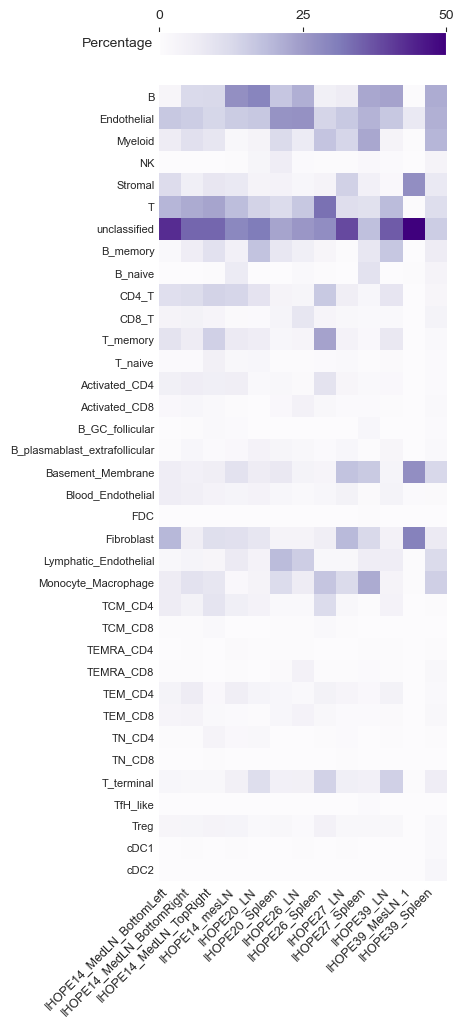

In [12]:
# Raw percentages:
plot_celltype_heatmap(
    matrix,
    scale = "linear",
    colorbar_legend="Percentage"
)

Clustered:

In [13]:
import importlib
import scripts.comparison as comparison

importlib.reload(comparison)

from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_heatmap,
    plot_celltype_clustermap
)


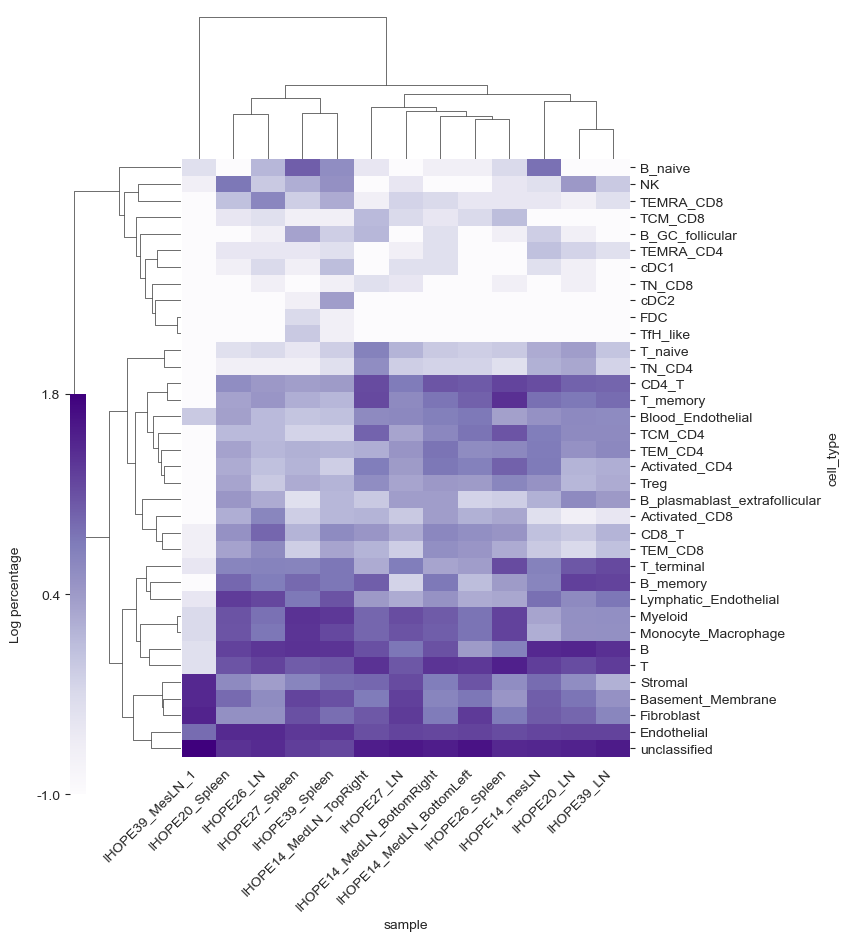

In [15]:
# Both axes

plot_celltype_clustermap(
    matrix,
    colorbar_legend="Log percentage",
    scale="log"
)

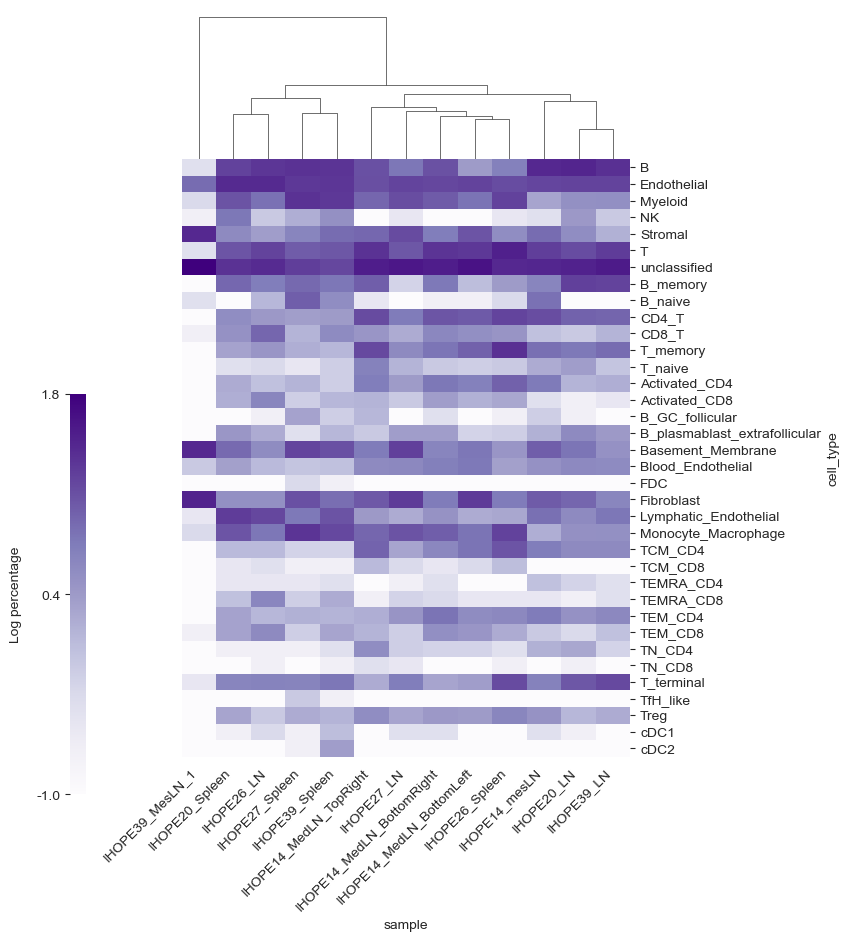

In [16]:
# Only cluster samples

plot_celltype_clustermap(
    matrix,
    colorbar_legend="Log percentage",
    scale="log",
    cluster_rows=False,
    cluster_cols=True
)

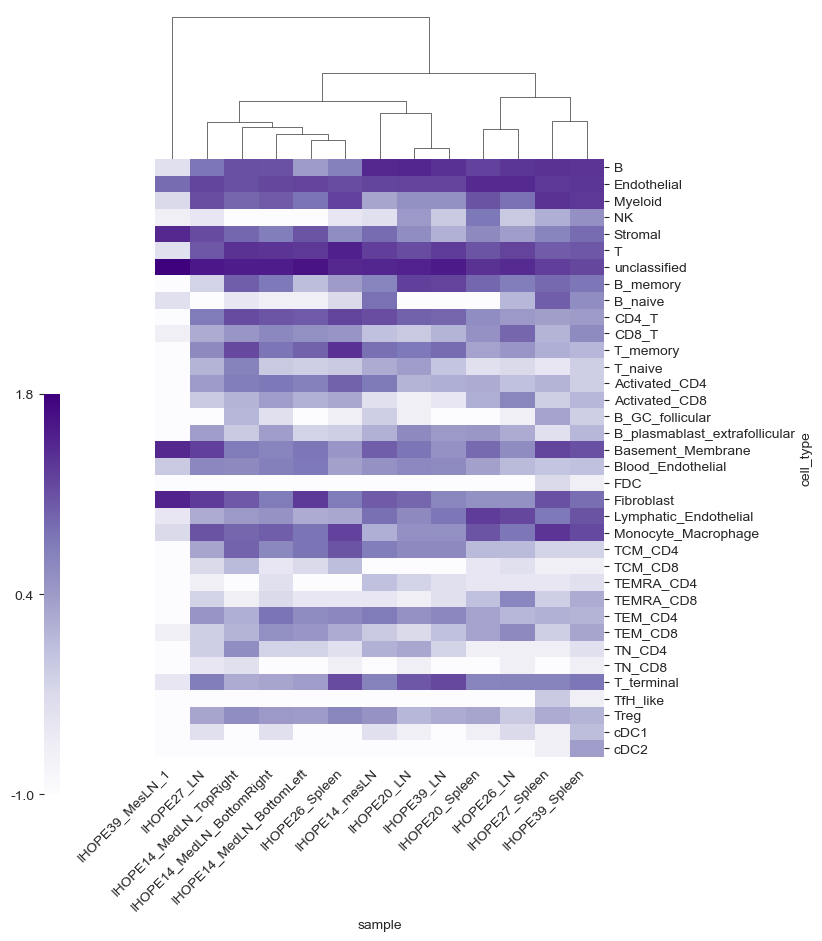

In [17]:
# With correlation metric instead of Euclidean

plot_celltype_clustermap(
    matrix,
    scale="log",
    cluster_rows=False,
    cluster_cols=True,
    metric="correlation"
)

Tissue type summary

In [18]:
tissue_map = {
    "IHOPE14_MedLN_BottomLeft": "MedLN",
    "IHOPE14_MedLN_BottomRight": "MedLN",
    "IHOPE14_MedLN_TopRight": "MedLN",
    "IHOPE14_mesLN": "MesLN",
    "IHOPE20_LN": "MedLN",
    "IHOPE20_Spleen": "Spleen",
    "IHOPE26_LN": "MedLN",
    "IHOPE26_Spleen": "Spleen",
    "IHOPE27_LN": "MedLN",
    "IHOPE27_Spleen": "Spleen",
    "IHOPE39_LN": "MedLN",
    "IHOPE39_MesLN_1": "MesLN",
    "IHOPE39_Spleen": "Spleen",
}

In [19]:
df = load_celltype_summaries(file_map=file_map)

df["tissue"] = df["sample"].map(tissue_map)

Using mean  (avoid dominance of large samples):

In [20]:
df_tissue = (
    df.groupby(["tissue", "level", "cell_type"], as_index=False)
      .agg(pct_total=("pct_total", "mean"))
)

In [21]:
import numpy as np
matrix_tissue = pivot_for_tissue_heatmap(df_tissue)

plot_matrix = np.log10(matrix_tissue + 0.1)

For log transformed percentages:

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/comparison.py:239: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


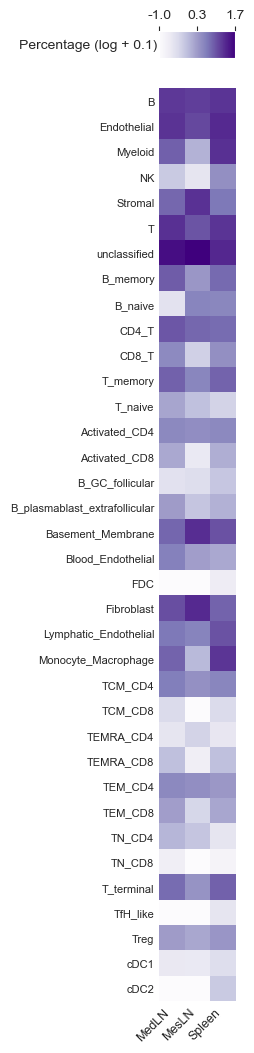

In [22]:
plot_celltype_heatmap(
    plot_matrix,
    colorbar_legend="Percentage (log + 0.1)",
    scale="log"
)

Raw percentages:

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/comparison.py:239: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


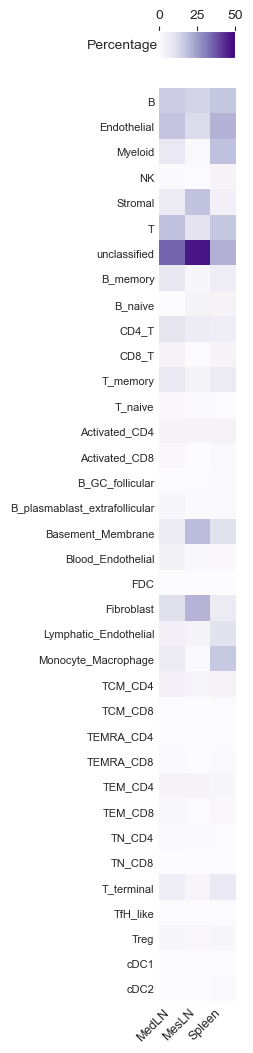

In [23]:
plot_celltype_heatmap(
    matrix_tissue,
    colorbar_legend="Percentage",
    scale="linear"
)

## Stacked barplot

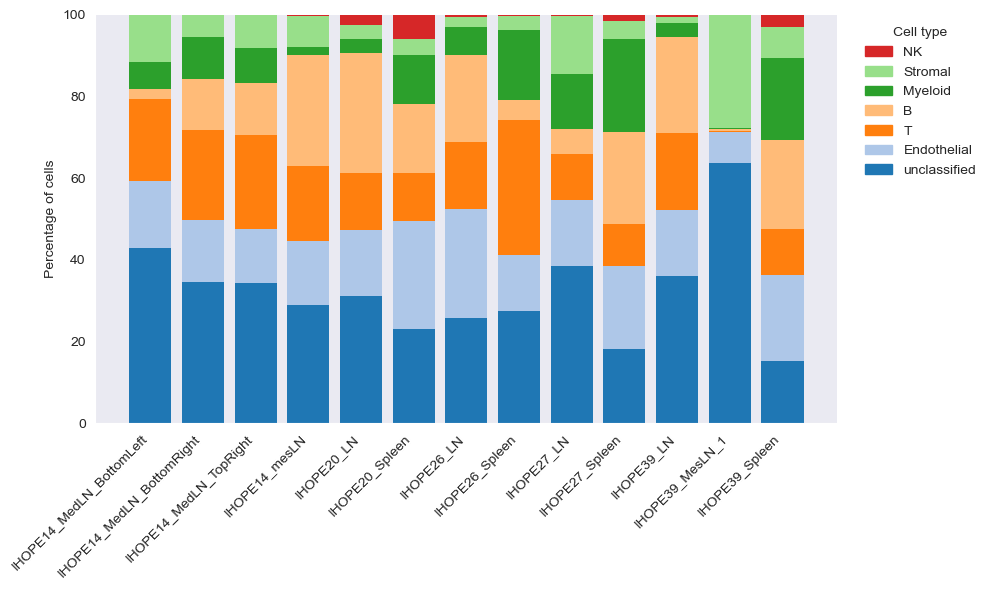

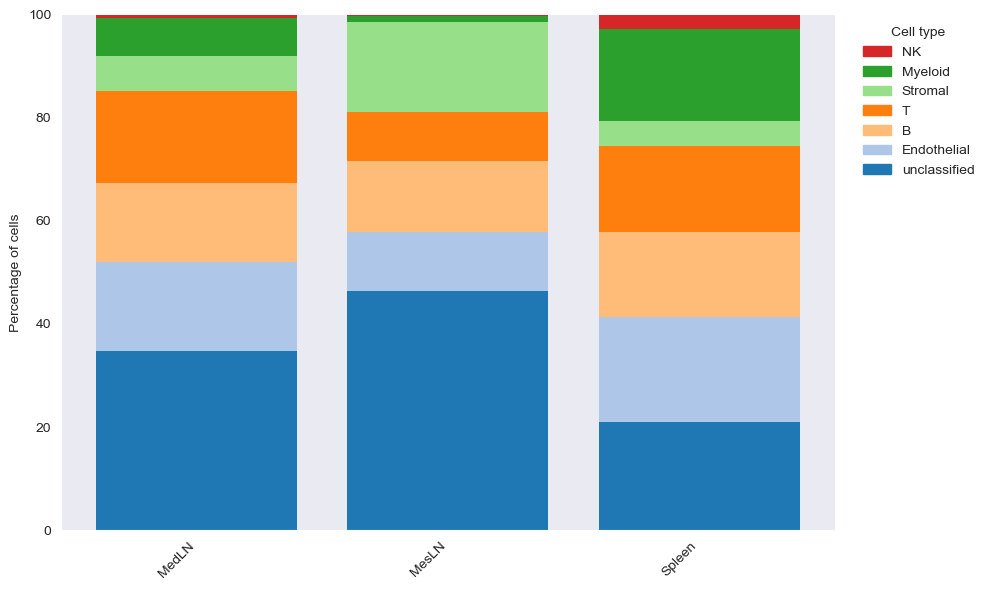

{'unclassified': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'Endothelial': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'T': (1.0, 0.4980392156862745, 0.054901960784313725),
 'B': (1.0, 0.7333333333333333, 0.47058823529411764),
 'Myeloid': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Stromal': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 'NK': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)}

In [30]:
importlib.reload(comparison)
from scripts.comparison import plot_celltype_stacked_barplot

palette = plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    ylim=(0,100)
)

plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    x="tissue",
    palette=palette,
    ylim=(0, 100)
)

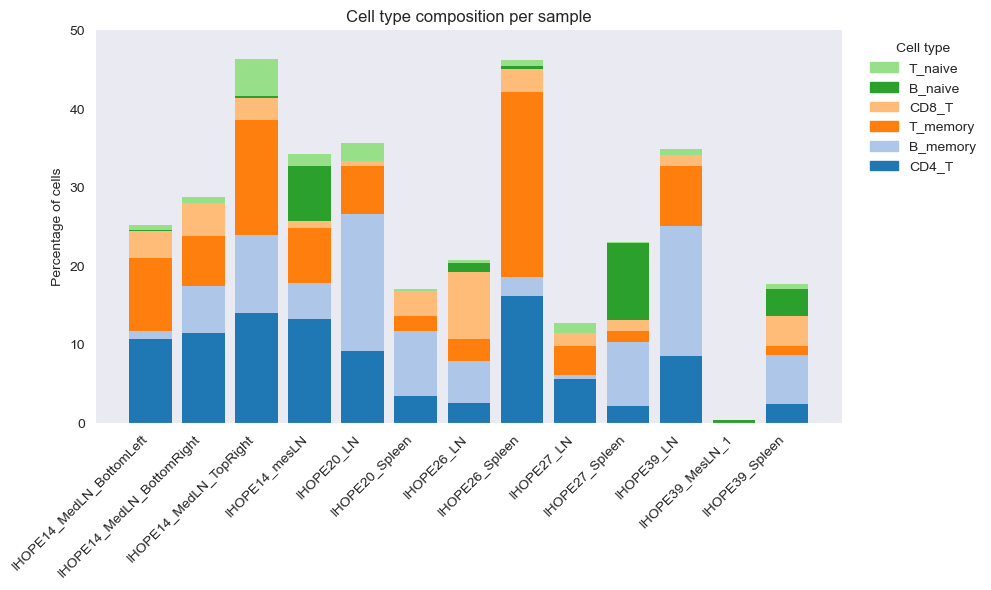

In [43]:
importlib.reload(comparison)
from scripts.comparison import plot_celltype_stacked_barplot

palette = plot_celltype_stacked_barplot(
    df,
    levels=["intermediate"],
    x="sample",
    title="Cell type composition per sample",
    ylim = (0, 50)
)

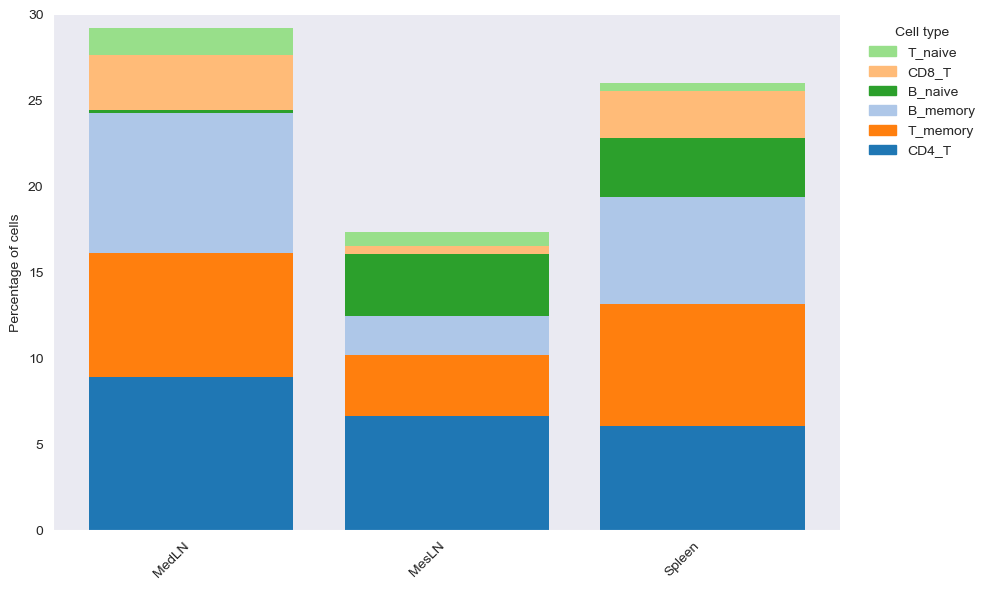

{'CD4_T': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'B_memory': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'T_memory': (1.0, 0.4980392156862745, 0.054901960784313725),
 'CD8_T': (1.0, 0.7333333333333333, 0.47058823529411764),
 'B_naive': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'T_naive': (0.596078431372549, 0.8745098039215686, 0.5411764705882353)}

In [46]:
importlib.reload(comparison)
from scripts.comparison import plot_celltype_stacked_barplot

plot_celltype_stacked_barplot(
    df_tissue,
    levels=["intermediate"],
    x="tissue",
    palette=palette,  # reuse colors
    ylim = (0, 30)
)